In [ ]:
importu sys
!{sys.executable} -m pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)


In [ ]:
import cv2
print(cv2.__version__)

4.13.0


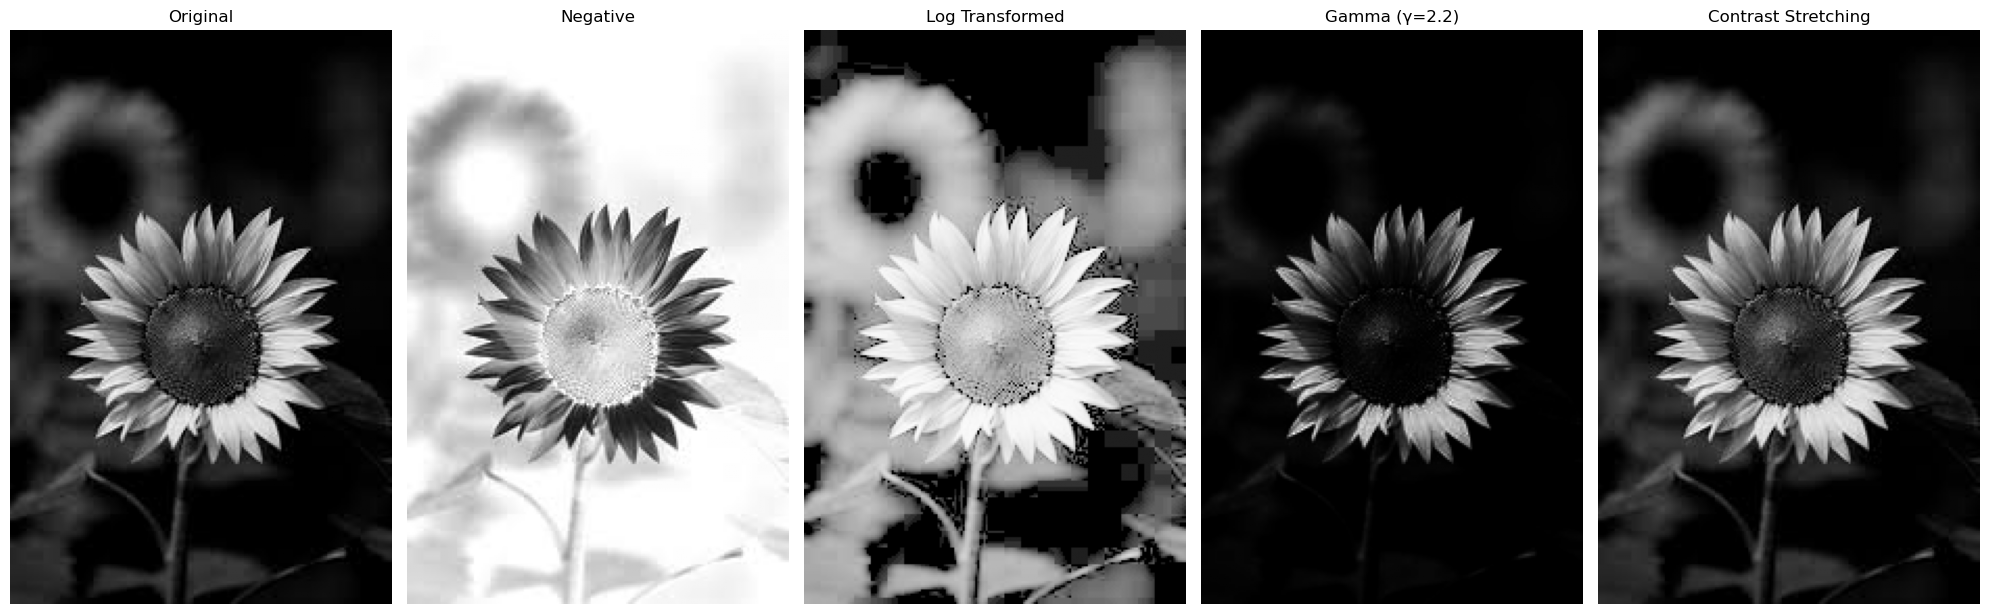

In [ ]:
#Write a python program to demonstrate the application of different intensity transformation techniques on a sample image


import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
# We'll load in Grayscale for clearer transformation results
img = cv2.imread("image1.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found. Please check 'image1.png' exists.")
else:
    # --- Transformation 1: Image Negative ---
    # Formula: s = (L - 1) - r
    img_negative = 255 - img

    # --- Transformation 2: Log Transformation ---
    # Formula: s = c * log(1 + r)
    img_float = img.astype(float)
    c = 255 / np.log(1 + np.max(img_float))
    img_log = c * np.log(1 + img_float)
    img_log = np.uint8(img_log)

    # --- Transformation 3: Power-Law (Gamma) Transformation ---
    # Formula: s = c * r^gamma
    gamma = 2.2  # Change this to see different effects (<1 brightens, >1 darkens)
    img_gamma = np.array(255 * (img / 255) ** gamma, dtype='uint8')

    # --- Transformation 4: Contrast Stretching ---
    # Formula: s = (r - rmin) * (255 / (rmax - rmin))
    r_min, r_max = np.min(img), np.max(img)
    img_stretch = (img.astype(float) - r_min) * (255 / (r_max - r_min))
    img_stretch = img_stretch.astype(np.uint8)

    # --- Displaying Results using Subplots ---
    titles = ['Original', 'Negative', 'Log Transformed', f'Gamma (γ={gamma})', 'Contrast Stretching']
    images = [img, img_negative, img_log, img_gamma, img_stretch]

    plt.figure(figsize=(20, 10))

    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
cv.imshow()